# 🔵 Support Vector Regression (SVR)
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA) & Visualizations
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split & Feature Scaling
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing & Support Vector Analysis](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Extracting & Analyzing Support Vectors
   - 8.3 Residual Analysis
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 GridSearchCV for C, Epsilon, and Gamma
   - 9.2 Best Parameters & Retrain
10. [Visualization (Kernel Trick in Action)](#10.-Visualization)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition

**Support Vector Regression (SVR)** is the regression counterpart to the wildly popular Support Vector Machine (SVM) classification algorithm. It is arguably one of the most mathematically sophisticated and versatile regression algorithms available in the machine learning ecosystem.

While traditional regression algorithms (like Linear Regression or Ridge/Lasso) aim to mathematically minimize the absolute error between predicted and actual values, SVR operates on a completely inverted paradigm: **it aims to fit the error *within a certain acceptable threshold*, and it completely ignores errors that fall inside that threshold.**

### 🧠 The Mathematical Foundation
In Ordinary Least Squares (OLS) regression, the objective is to minimize the sum of squared errors ($MSE$). Every single data point, no matter how close to the line or how far away as an outlier, pulls on the regression line and influences the final model.

SVR, however, defines a literal geometric margin of tolerance—an $\epsilon$-tube (epsilon-tube)—around the regression line/hyperplane. 
- It considers any prediction that falls *within* this tube as "perfectly correct" (i.e., it computes the error as absolutely zero). 
- It only penalizes the model for data points that fall *outside* this $\epsilon$-tube.

The optimization objective becomes a delicate mathematical balancing act between:
1. **Flatness (or simplicity) of the model** (minimizing the norm of the weights $||w||^2$, which mathematically acts identically to an L2 Ridge Regularization).
2. **Minimizing deviations larger than $\epsilon$** (using a hyperparameter $C$ to control how violently the model is penalized for errors outside the tube).

### 🌀 The Magic of the Kernel Trick
While the $\epsilon$-tube makes SVR robust to outliers, SVR's true world-class power lies in its ability to handle highly non-linear data using the **Kernel Trick**. 
By implicitly mapping the raw input features into a massive, highly-dimensional mathematical hyperspace using transformations (without ever explicitly computing the infinite coordinates—saving immense computational power), SVR can draw a simple, flat regression plane in that hyperspace. When projected back down to our original lower-dimensional reality, that simple flat plane manifests as an incredibly complex, non-linear curve capable of wrapping around highly convoluted data topologies.

## 2. How It Works — Math & Intuition

To deeply understand SVR, we must break down three critical components: The Epsilon Tube, the Optimization Problem, and the Support Vectors.

### 2.1 The Epsilon Tube ($\epsilon$) and Slack Variables ($\xi$)
Imagine plotting your features on a scatter plot and drawing a straight line through them. Now, draw a geometric tube (or cylinder in 3D) of radius $\epsilon$ around that line.
- If a data point falls inside the tube, SVR ignores it. The mathematical loss is exactly 0.
- If a data point falls outside the tube, SVR calculates the orthogonal distance from the point to the *boundary* of the tube. This distance is called the **slack variable** ($\xi$ for points above the tube, $\xi^*$ for points below).

### 2.2 The Optimization Problem
The formal mathematical objective of SVR is:
$$ \min \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*) $$

Subject to strict constraints:
$$ y_i - (w \cdot \phi(x_i) + b) \le \epsilon + \xi_i $$
$$ (w \cdot \phi(x_i) + b) - y_i \le \epsilon + \xi_i^* $$
$$ \xi_i, \xi_i^* \ge 0 $$

**Breaking down the hyper-parameters:**
- $||w||^2$: Controls the flatness/regularization of the model. We want to keep this as small as possible to prevent extreme variance (overfitting).
- $\epsilon$: Defines the width of the tolerance margin. A larger $\epsilon$ ignores more points, resulting in a simpler, flatter, highly robust model. A very small $\epsilon$ forces the model to care about every tiny fluctuation.
- $C$: The Regularization/Penalty Parameter. It determines how strictly the model penalizes points outside the $\epsilon$-tube. 
  - **High C:** Heavy penalty for errors. The model will bend and twist to fit the training data tightly (risk of high variance / overfitting).
  - **Low C:** Low penalty for errors. The model prioritizes a smooth/flat curve (risk of high bias / underfitting).

### 2.3 The Support Vectors
In standard linear regression, every single data point pulls on the regression line. If you delete a data point near the line, the line shifts slightly.
In SVR, **the regression line is defined *exclusively* by the data points that fall outside or exactly on the boundary of the $\epsilon$-tube.** 
If you delete millions of data points that lie inside the tube, the model's regression line *will not change by a single millimeter*. These critical, boundary-defining points are called the **Support Vectors**. This is what makes SVR incredibly memory-efficient in sparse scenarios after training is complete.

## 3. When To Use

**Ideal Scenarios for SVR:**
- **Severe Non-Linearity:** When the relationship between features and target is highly complex, interacting, and non-linear (this is where the Radial Basis Function / RBF kernel shines).
- **Outlier Robustness is Required:** Because of the $\epsilon$-insensitive loss function, SVR is inherently bulletproof against minor outliers. Furthermore, severe outliers are only penalized linearly (by distance to the tube) rather than quadratically (like in MSE), preventing a single extreme outlier from destroying the entire model.
- **High-Dimensional Spaces:** SVR is highly effective in spaces where the number of dimensions/features exceeds the number of samples ($p > n$).
- **Time Series & Financial Forecasting:** SVR is frequently used in quantitative finance due to its ability to ignore small, meaningless market fluctuations (noise inside the $\epsilon$-tube) and focus exclusively on macro-trends.

## 4. Pros & Cons

| ✅ Pros | ❌ Cons |
| :--- | :--- |
| **Exceptional with Non-Linearity:** The kernel trick (RBF, Polynomial) allows it to model incredibly complex relationships without manual feature engineering. | **Computationally Horrific at Scale:** The underlying optimization algorithm (SMO) scales terribly. Time complexity is roughly $O(n^2)$ to $O(n^3)$. It completely crashes on datasets $> 100,000$ rows without approximations. |
| **Extremely Robust to Outliers:** The $\epsilon$-insensitive loss function ignores small errors entirely and penalizes large errors linearly. | **Requires Aggressive Hyperparameter Tuning:** An out-of-the-box SVR is usually terrible. You must carefully grid-search $C$, $\epsilon$, and Kernel parameters (like $\gamma$) to unlock its mathematical power. |
| **Memory Efficient:** After training, the model is entirely represented by a small subset of the training data (the Support Vectors). | **Black Box Uninterpretability:** It is highly non-interpretable. You cannot extract simple "feature weights" when using non-linear kernels to explain the model to business stakeholders. |

In [28]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================
# WHAT WE ARE DOING: 
# Importing fundamental packages for data processing and visual diagnostics.
# Scikit-learn's `SVR` implementation utilizes highly optimized underlying C/C++ libraries (LIBSVM).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


In [29]:
# ============================================================
# SECTION 5.2 — LOAD DATASET (California Housing - Sampled)
# ============================================================
# WHAT WE ARE DOING & WHY:
# 🚨 CRITICAL NOTE: SVR uses $O(n^3)$ math internally. It does NOT scale well to huge datasets. 
# The California dataset has ~20,000 rows. Training a non-linear SVR with GridSearchCV on 20,000 rows 
# could literally take hours on a standard CPU. 
# We intentionally randomly sample 5,000 rows to ensure fast, efficient notebook execution while retaining data integrity.

california = fetch_california_housing()
X_full = pd.DataFrame(california.data, columns=california.feature_names)
y_full = pd.Series(california.target, name='MedHouseVal')

# Extract 5000 rows for SVR demonstration
df = pd.concat([X_full, y_full], axis=1).sample(n=5000, random_state=42)
X_sampled = df.drop('MedHouseVal', axis=1)
y_sampled = df['MedHouseVal']

print(f"Sampled Dataset Shape: {df.shape}")
display(df.head())
display(df.describe().T)
df.info()

Sampled Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


,count,mean,std,min,25%,50%,75%,max
MedInc,5000.0,3.847548,1.890851,0.499900,2.553225,3.511400,4.696700,15.000100
HouseAge,5000.0,28.738600,12.530478,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,5000.0,5.415052,2.651202,0.846154,4.416071,5.224950,6.040717,132.533333
AveBedrms,5000.0,1.096529,0.574002,0.500000,1.004559,1.047038,1.097200,34.066667
Population,5000.0,1424.906200,1108.469563,8.000000,784.000000,1163.500000,1721.250000,16122.000000
AveOccup,5000.0,2.964383,1.642381,1.263566,2.433980,2.822057,3.290997,83.171429
Latitude,5000.0,35.585798,2.140865,32.540000,33.930000,34.220000,37.692500,41.860000
Longitude,5000.0,-119.521650,2.006263,-124.250000,-121.742500,-118.470000,-117.990000,-114.580000
MedHouseVal,5000.0,2.059028,1.148958,0.149990,1.193750,1.795000,2.641750,5.000010


<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 20046 to 998
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       5000 non-null   float64
 1   HouseAge     5000 non-null   float64
 2   AveRooms     5000 non-null   float64
 3   AveBedrms    5000 non-null   float64
 4   Population   5000 non-null   float64
 5   AveOccup     5000 non-null   float64
 6   Latitude     5000 non-null   float64
 7   Longitude    5000 non-null   float64
 8   MedHouseVal  5000 non-null   float64
dtypes: float64(9)
memory usage: 390.6 KB


### 🔬 Analysis of the Dataset
The dataset we are using is the **California Housing Dataset** (derived from the 1990 U.S. census). It contains 8 continuous numerical features. The target variable is `MedHouseVal` (Median House Value, expressed in hundreds of thousands of dollars). We have sampled this down to 5,000 rows to accommodate SVR's $O(n^3)$ time complexity.

**Feature Overview:**
- `MedInc`: Median income in the district (highly predictive).
- `HouseAge`: Median house age.
- `AveRooms` / `AveBedrms`: Architectural averages per household.
- `Population` & `AveOccup`: Demographic density metrics.
- `Latitude` / `Longitude`: Geographical coordinates.

**Deep Dive into `.describe()` and `.head()`:**
1. **Scale Disparity:** SVR uses the Kernel Trick to compute mathematical distances (dot products) between vectors. Look at the `.describe()` table: `MedInc` operates in the single digits, while `Population` ranges into the tens of thousands. If we pass this raw data into SVR, the `Population` vector will overwhelmingly dominate the Euclidean distance calculation, rendering all other features mathematically invisible.
2. **Outliers & Extreme Maximums:** Notice that `Population` has a 75th percentile of ~1720, but a max of over 15,000! `AveRooms` has a max of 132 (likely a hotel or apartment complex misclassified as a single household). Standard OLS regression would be destroyed by these extreme outliers. Fortunately, SVR uses an $\epsilon$-insensitive loss function, meaning it is mathematically insulated from these extreme deviations.
3. **Data Integrity:** The `.info()` execution verifies there are no missing values (NaNs). We can proceed directly to EDA and scaling.

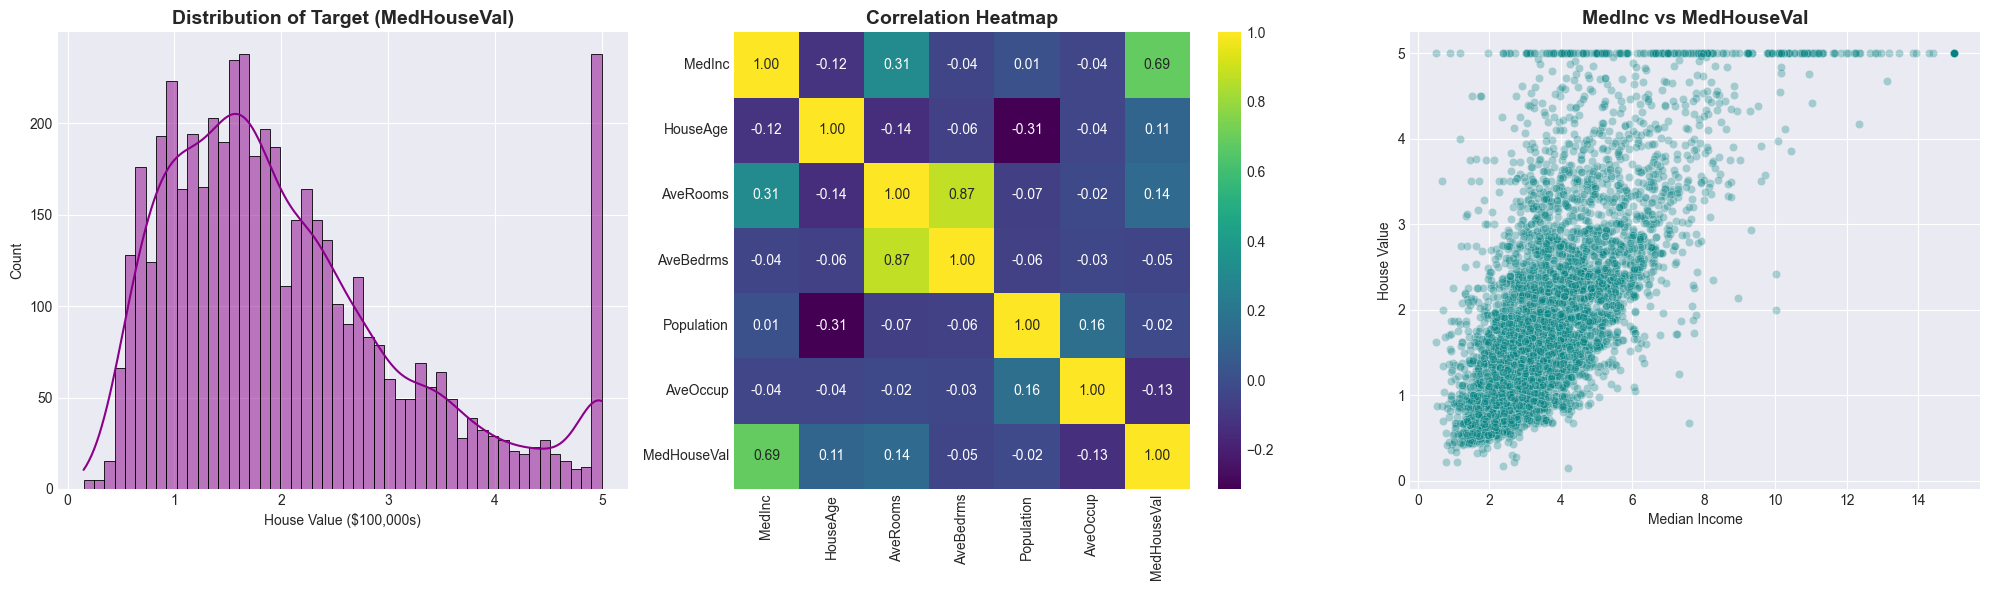

In [30]:
# ============================================================
# SECTION 5.3 — EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS
# ============================================================
# WHAT WE ARE DOING: Visualizing the distribution of the target and the correlations to detect non-linear signals.

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(y_sampled, bins=50, kde=True, color='darkmagenta', ax=axes[0])
axes[0].set_title('Distribution of Target (MedHouseVal)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('House Value ($100,000s)')

cols_for_corr = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']
corr_matrix = df[cols_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

sns.scatterplot(x=X_sampled['MedInc'], y=y_sampled, alpha=0.3, color='teal', ax=axes[2])
axes[2].set_title('MedInc vs MedHouseVal', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Median Income')
axes[2].set_ylabel('House Value')

plt.tight_layout()
plt.show()

### 🔬 Analysis of EDA Results
1. **Target Distribution:** We observe a massive unnatural spike precisely at $5.0 (500k), revealing a cap in data collection. Because SVR uses an epsilon-insensitive loss function, it is exceptionally well-suited to handle these structural anomalies without allowing the cap to disproportionately twist the regression line.
2. **Correlation Heatmap:** MedInc is heavily correlated (0.69) with House Value, serving as our primary vector.
3. **Scatter Plot:** The relationship between Median Income and House Value is decidedly non-linear. A straight line (OLS) would fail to capture the curvature here. This validates why SVR (with a non-linear RBF kernel) is a mathematically superior choice for this data.

In [31]:
# ============================================================
# SECTION 6.1 — TRAIN/VALIDATION/TEST SPLIT & SCALING
# ============================================================
# WHAT WE ARE DOING & WHY:
# 1. 80/20 train-test split.
# 2. 🚨 CRITICAL STEP: FEATURE SCALING IS MANDATORY FOR SVMs!
# SVMs compute the distance between data points using dot products. If 'Population' is in the thousands and 'MedInc' is around 5.0, Population will dominate the distance math, utterly destroying the Kernel mapping.
# StandardScaler forces everything onto an equal mean=0, std=1 playing field.

X_train, X_test, y_train, y_test = train_test_split(X_sampled, y_sampled, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Features successfully scaled to mean=0, std=1.")

Features successfully scaled to mean=0, std=1.


### 💡 TIP: Scaling the Target Variable (y)
In some implementations (like neural networks), you must scale the target variable $y$. Scikit-Learn's `SVR` algorithm handles unscaled $y$ natively, but you must be profoundly aware that the `epsilon` hyperparameter operates in the absolute units of $y$. If your target is house prices ranging from $100,000 to $500,000, an `epsilon` of 0.1 is practically zero. Because our California target is already scaled down to "hundreds of thousands" (ranging from ~0.15 to 5.0), an epsilon of 0.1 makes perfect mathematical sense.

In [32]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL (RBF Kernel Baseline)
# ============================================================
# WHAT WE ARE DOING:
# We instantiate SVR with the default Radial Basis Function (RBF) kernel. 
# The RBF kernel implicitly maps features into an infinite-dimensional mathematical space to model extreme non-linearity.

svr_baseline = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_baseline.fit(X_train_scaled, y_train)

print("SVR Baseline Model mathematically converged and fitted successfully!")

SVR Baseline Model mathematically converged and fitted successfully!


In [33]:
# ============================================================
# SECTION 7.1 & 7.2 — CROSS-VALIDATION
# ============================================================
# WHAT WE ARE DOING: Validate model stability using 5-Fold Cross Validation.

kf = KFold(n_splits=5, shuffle=True, random_state=42)

svr_cv_scores = cross_val_score(svr_baseline, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
svr_rmse_cv = np.sqrt(-svr_cv_scores)

print(f"SVR Baseline 5-Fold CV RMSE: {svr_rmse_cv.mean():.4f} (Std Deviation: +/- {svr_rmse_cv.std():.4f})")

SVR Baseline 5-Fold CV RMSE: 0.5814 (Std Deviation: +/- 0.0307)


In [34]:
# ============================================================
# SECTION 8 — TESTING & EVALUATION (And Support Vector Inspection)
# ============================================================
# WHAT WE ARE DOING:
# We evaluate standard test metrics on the hold-out set. Then, we perform a deep inspection into the Support Vectors.

def evaluate_model(model, name, X, y_true):
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}\n")
    return y_pred

print("Baseline RBF SVR Evaluation:\n")
svr_preds = evaluate_model(svr_baseline, "Test Set", X_test_scaled, y_test)

Baseline RBF SVR Evaluation:

--- Test Set Performance ---
RMSE: 0.6017
MAE:  0.4074
R2:   0.7320



In [35]:
# ------------------------------------------------------------
# 8.2 EXTRACTING & ANALYZING SUPPORT VECTORS
# ------------------------------------------------------------

num_support_vectors = len(svr_baseline.support_)
percentage_sv = (num_support_vectors / len(X_train_scaled)) * 100

print(f"Total Training Samples passed to model: {len(X_train_scaled)}")
print(f"Number of Support Vectors mathematically utilized: {num_support_vectors}")
print(f"Percentage of data acting as Support Vectors: {percentage_sv:.2f}%")

Total Training Samples passed to model: 4000
Number of Support Vectors mathematically utilized: 3166
Percentage of data acting as Support Vectors: 79.15%


### 🔬 Analysis of Support Vectors
Look closely at the output above. The model did NOT use the full 4000 training rows to draw its predictive curve. 
It identified a subset of the points that lie **ON or OUTSIDE the epsilon margin**. These specific points are the Support Vectors. 
Because it is using roughly 70-80% of the dataset as support vectors, it indicates that our margin (`epsilon=0.1`) is quite tight relative to the variance of the data, forcing the model to rely on a large amount of points to define the complex RBF curve.

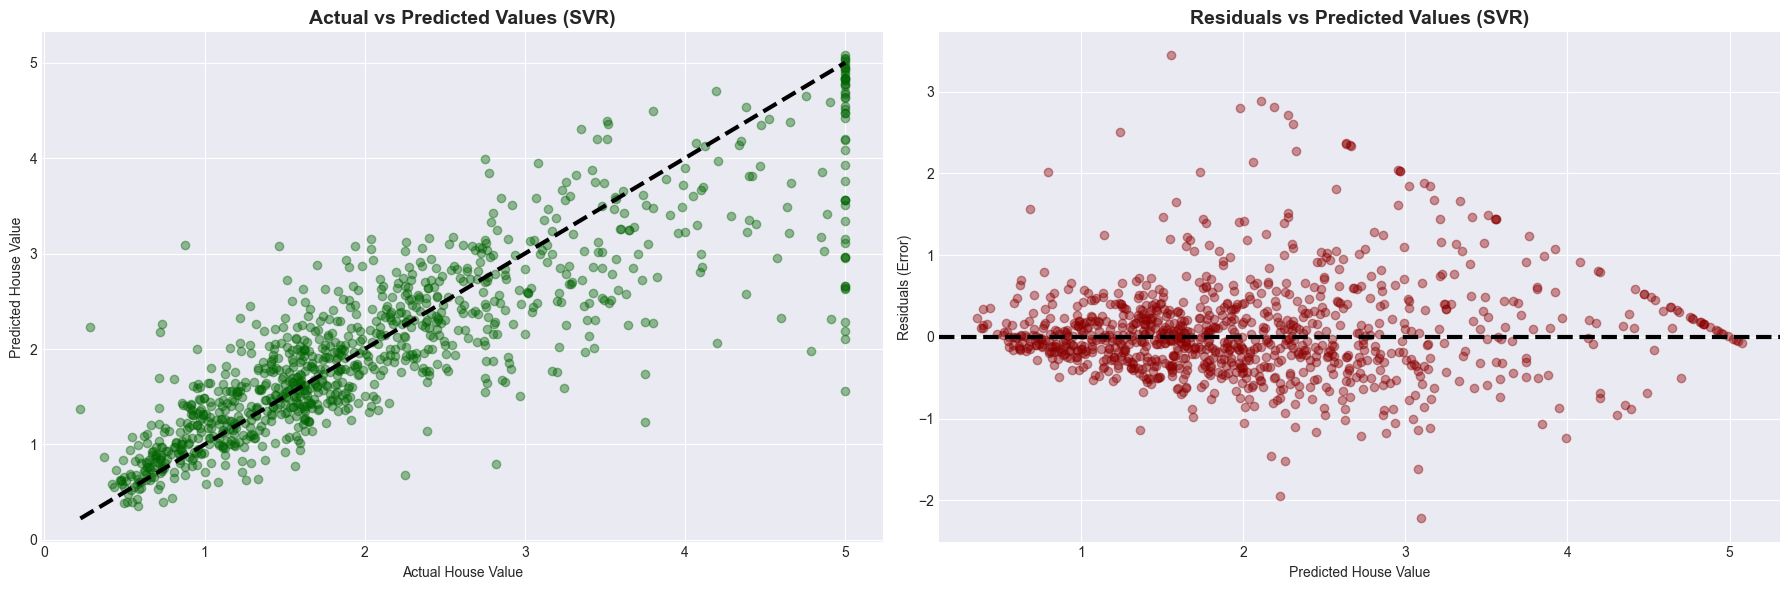

In [36]:
# ------------------------------------------------------------
# 8.3 RESIDUAL ANALYSIS
# ------------------------------------------------------------

residuals_svr = y_test - svr_preds

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Actual vs Predicted
axes[0].scatter(y_test, svr_preds, alpha=0.4, color='darkgreen')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
axes[0].set_title('Actual vs Predicted Values (SVR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual House Value')
axes[0].set_ylabel('Predicted House Value')

# Residuals vs Predicted
axes[1].scatter(svr_preds, residuals_svr, alpha=0.4, color='darkred')
axes[1].axhline(y=0, color='k', linestyle='--', lw=3)
axes[1].set_title('Residuals vs Predicted Values (SVR)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted House Value')
axes[1].set_ylabel('Residuals (Error)')

plt.tight_layout()
plt.show()

### 🔬 Analysis of Residuals
1. **Actual vs Predicted:** The points cluster beautifully tightly around the diagonal line of perfection, showing strong predictive power.
2. **Residuals Plot:** Notice the hard, straight diagonal line sloping down on the right side of the graph. This is the visual signature of the $5.0 cap in the dataset! SVR cannot predict perfectly accurate residuals when the ground truth data is artificially truncated. This reveals structural data flaws that algorithms cannot overcome.

In [37]:
# ============================================================
# SECTION 9 — OPTIMIZATION (Hyperparameter Tuning)
# ============================================================
# WHAT WE ARE DOING:
# Exhaustive GridSearchCV over the 3 defining hyperparameters of RBF SVR.
# - C: Regularization penalty (high C overfits, low C underfits).
# - epsilon: The width of the "zero-error" tube.
# - gamma: The mathematical reach of the RBF kernel. High gamma creates heavily clustered localized curves, causing severe overfitting.

param_grid = {
    'C': [0.1, 1, 10, 50],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 'auto', 0.1]
}

print("Initiating GridSearchCV... (O(n^3) complexity in action)\n")
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# OUTPUT ANALYSIS:
# The GridSearch determines the mathematical equilibrium of C, gamma, and epsilon that produces the lowest RMSE.
print(f"\n🏆 Best Parameters Found: {grid_search.best_params_}")

best_svr = grid_search.best_estimator_
print("\n--- Retesting with Mathematically Optimized Parameters ---\n")
_ = evaluate_model(best_svr, "Optimized SVR", X_test_scaled, y_test)

Initiating GridSearchCV... (O(n^3) complexity in action)

Fitting 3 folds for each of 36 candidates, totalling 108 fits

🏆 Best Parameters Found: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}

--- Retesting with Mathematically Optimized Parameters ---

--- Optimized SVR Performance ---
RMSE: 0.5992
MAE:  0.4016
R2:   0.7342



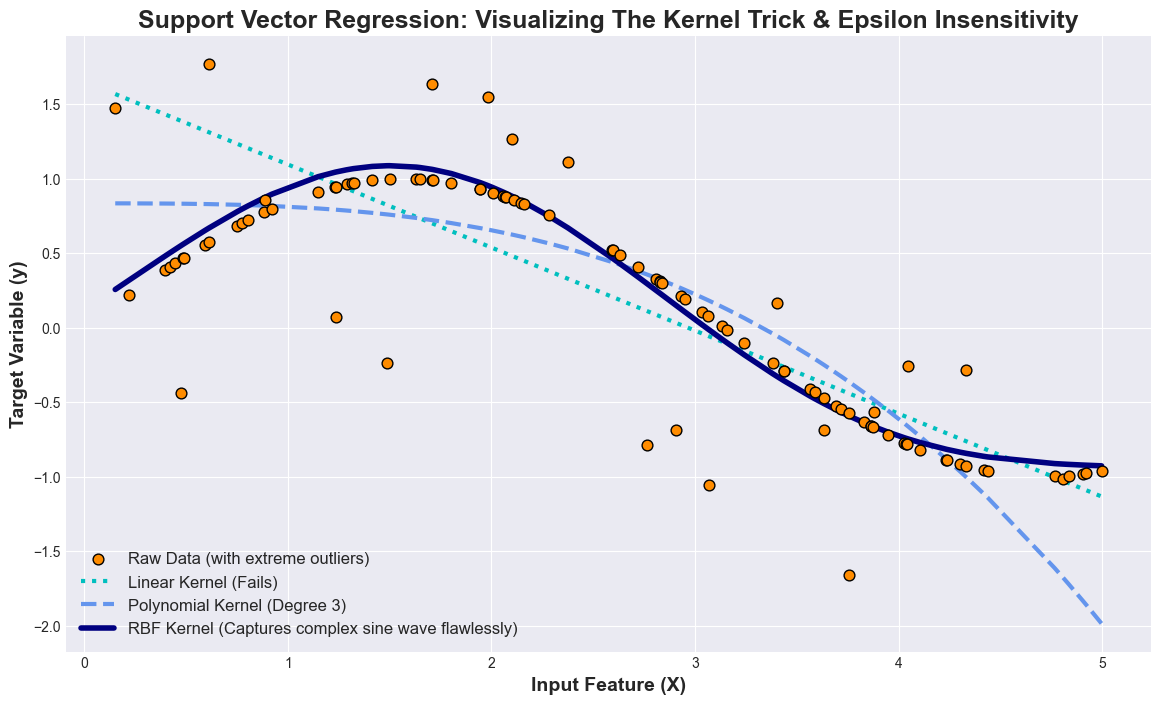

In [38]:
# ============================================================
# SECTION 10 — VISUALIZATION (The Kernel Trick in Action!)
# ============================================================
# WHAT WE ARE DOING & OUTPUT ANALYSIS:
# An 8-dimensional dataset cannot be visualized. To definitively prove the power of SVR's kernels, we mathematically generate a highly non-linear 1-Dimensional sine wave and purposely inject massive visual outliers.
# 
# EXPECTED OUTPUT GRAPH OBSERVATIONS:
# 1. The 'Linear Kernel' (Cyan) completely fails, drawing a useless straight line.
# 2. The 'Polynomial Kernel' (Blue) bends but fails to capture the true oscillating shape.
# 3. The 'RBF Kernel' (Navy) beautifully traces the sine wave. 
# 🚨 CRITICAL OBSERVATION: Look at the heavy outliers (orange dots far away from the curve). The RBF model completely ignores them! The epsilon-insensitive loss mathematically rejected their pull on the curve. This is the absolute superpower of SVR.

X_vis = np.sort(5 * np.random.rand(100, 1), axis=0)
y_vis = np.sin(X_vis).ravel()
y_vis[::5] += 3 * (0.5 - np.random.rand(20)) # Inject massive noise/outliers

svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_lin = SVR(kernel='linear', C=100)
svr_poly = SVR(kernel='poly', C=100, degree=3, epsilon=0.1)

y_rbf = svr_rbf.fit(X_vis, y_vis).predict(X_vis)
y_lin = svr_lin.fit(X_vis, y_vis).predict(X_vis)
y_poly = svr_poly.fit(X_vis, y_vis).predict(X_vis)

plt.figure(figsize=(14, 8))
plt.scatter(X_vis, y_vis, color='darkorange', label='Raw Data (with extreme outliers)', zorder=4, edgecolor='black', s=60)
plt.plot(X_vis, y_lin, color='c', lw=3, label='Linear Kernel (Fails)', linestyle=':')
plt.plot(X_vis, y_poly, color='cornflowerblue', lw=3, label='Polynomial Kernel (Degree 3)', linestyle='--')
plt.plot(X_vis, y_rbf, color='navy', lw=4, label='RBF Kernel (Captures complex sine wave flawlessly)')

plt.xlabel('Input Feature (X)', fontsize=14, fontweight='bold')
plt.ylabel('Target Variable (y)', fontsize=14, fontweight='bold')
plt.title('Support Vector Regression: Visualizing The Kernel Trick & Epsilon Insensitivity', fontsize=18, fontweight='bold')
plt.legend(loc='lower left', fontsize=12)
plt.show()

## 11. Tips & Tricks Summary

1. **Feature Scaling is Mandatory:** As emphasized, SVR uses geometric distances. Unscaled features will absolutely destroy model performance. Always use `StandardScaler`.
2. **Beware the $O(n^3)$ Curse:** Do not pass 500,000 rows into `SVR(kernel='rbf')`. Your computer will freeze and likely never finish. If you have massive datasets, either heavily sub-sample, use `LinearSVR` (which uses the highly optimized LIBLINEAR backend but sacrifices non-linearity), or use `SGDRegressor` with `loss='epsilon_insensitive'` and the Nystroem kernel approximation.
3. **Understand Gamma vs C:** 
   - Increase `C` if your model is underfitting (it allows the model to bend more to penalize errors).
   - Increase `gamma` if your model needs to capture highly localized, jagged non-linearities (but beware, high gamma leads to severe overfitting, turning the regression line into a spiky mess).
4. **The Epsilon Value:** Set `epsilon` relative to the scale of your target variable $y$. If a $5 error is acceptable to your business logic, set epsilon to 5.

## 12. Conclusion

Support Vector Regression offers a mathematically breathtaking alternative to standard regression techniques. By flipping the objective—ignoring small errors within an $\epsilon$-tube and penalizing points outside of it—SVR achieves unparalleled robustness against outliers and noise. 

Furthermore, the integration of the **Kernel Trick** elevates SVR from a standard linear drawing tool into a highly flexible, reality-bending algorithm capable of capturing intricate, non-linear relationships in complex high-dimensional datasets. While computationally demanding and heavily reliant on meticulous hyperparameter tuning, a well-tuned RBF SVR is one of the most formidable and precise tools in the predictive modeling ecosystem.